## Tomographic reconstruction 

This notebook is used for obtaining a 3D volume from a series of projections, usually obtained from a ptycho-tomography scan. 

The reconstruction process includes: 
- Uploading the data
- Phase unwrapping of data
- Doing vertical motion correction of the data
- Doing horizontal motion correction of the data
- 3D reconstructing 

In [2]:
import sys
#sys.path.append('/dls_sw/i13-1/scripts/i13_gitlab/data_processing/')
# sys.path.append('/dls_sw/apps/tomopy/tomopy/src')

import tomopy
from tomopy.recon.rotation import find_center
import numpy as np
import utils_tomo as utils
from hdf5plugin import Blosc

import logging
import warnings
warnings.filterwarnings('ignore')
logger = logging.getLogger()
logger.setLevel(logging.CRITICAL)

import matplotlib.pyplot as plt
import time
from scipy.ndimage import gaussian_filter
from scipy import fft, optimize
from skimage.registration import phase_cross_correlation as register_translation

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
%matplotlib inline

from Imports import ImportData
from OpenViewer import OpenViewer
from TomoRecon import get_volume
from Unwrap import Unwrap

In [3]:
# This file should point to all the projections (already retrieved and ready to go). It's a nexus file (?). 
ptytomofile = 'C:/Users/zvm34551/Coding_environment/DATA/Ptychography/pty_tomo_NX.h5'



In [4]:
data = ImportData(ptytomofile)
projections_raw, angles, probes = data.get_projections_raw(), data.get_angles(), data.get_probes()

<KeysViewHDF5 ['entry1']>
raw data shape: (1000, 2217, 3097)
projections shape: (1000, 2217, 3097)
angles shape: (1000,)
Angles go from 0.0 to 3.1415927.
Loading dataset took 73.43262720108032 seconds.


In [5]:
OpenViewer(projections_raw)

Auto range for volume:  -0.09266343644639052 0.2004272259608677


In [6]:
projections_in = np.copy(projections_raw) # copy the raw projections so that we don't lose them
projections_in = np.amin(projections_in) - projections_in # ???

In [ ]:
Unwrap(projections_in, True)
OpenViewer(projections_in)


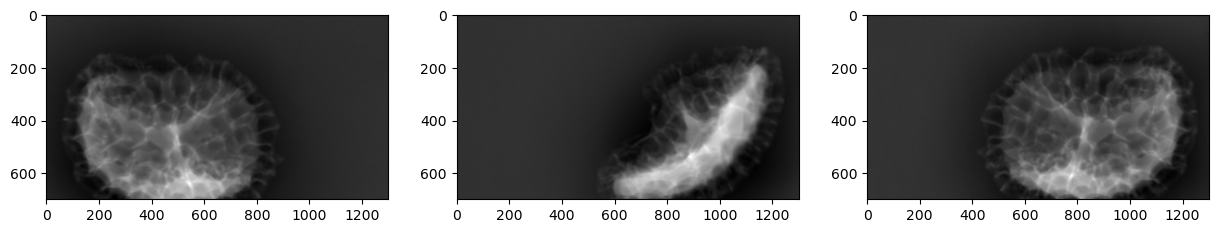

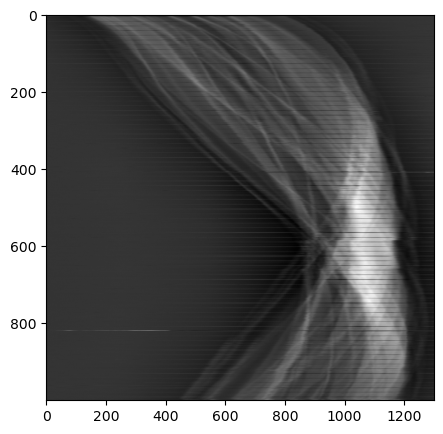

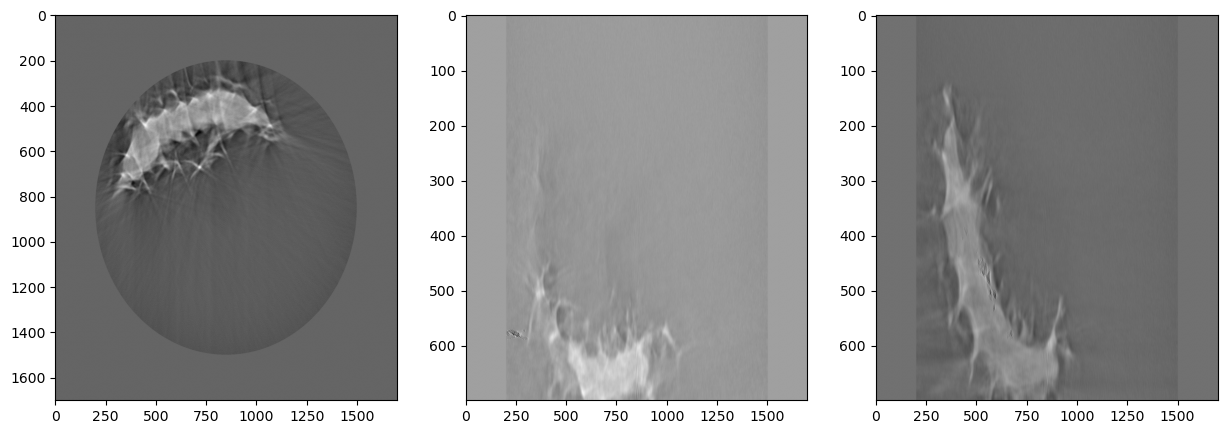

In [9]:
crop_window = [700,1400,1000,2300] # [y1, y2, x1, x2] where y is vertical and x is horizontal
projections_crop = projections_in[:,crop_window[0]:crop_window[1],crop_window[2]:crop_window[3]]

# plot the cropped projections and sinogram
utils.plot_3_projections(projections_crop)
utils.plot_sinogram(projections_crop)

# Reconstruct including all the "dead" frames, i.e. those acquired during beam dumping
volume_gridrec_beamDumping = get_volume(projections_crop, angles, centre=None, pad=200, algorithm='GRIDREC', iterations=1)
utils.plot_volume(volume_gridrec_beamDumping)

## Corrections / Normalise

In [10]:
# function to remove stripes caused by beam dumping every ~10 minutes
def remove_stripes(projs, angles, threshold= 0.02):
    mid_1 = projs.shape[1]//2
    mid_2 = projs.shape[2]//2
    line = np.abs(np.sum(projs[:,mid_1,:], axis = 1))

    cutoff = np.mean(line)+np.mean(line)*threshold
    good_projs = np.where(line<cutoff)
    projs_out = projs[np.array(good_projs),:,:][0]
    angles_out = angles[np.array(good_projs)][0]
    
    return projs_out, angles_out

# the difference between this function below and the one above is that we normalise the sinogram before the stripe removal
# and that we use both the maximum and the median to determine which lines to remove. 
def remove_stripes_oriol(projs, angles, threshold= 0.3):
    mid_1 = projs.shape[1]//2
    
    pp = np.zeros_like(projs[:,0,:])
    projs_sum_sino = np.sum(projs[:,mid_1:mid_1+10,:],axis=1)
    for i in range(projs.shape[0]):
        pp[i,:] = projs_sum_sino[i,:]/np.mean(projs[i,0:100])
    
    line = np.abs(np.sum(pp[:,:], axis = 1))

    median = np.median(line)
    maximum = np.max(line)

    cutoff = median + (maximum-median)*threshold
    good_projs = np.where(line<cutoff)
    projs_out = projs[np.array(good_projs),:,:][0]
    angles_out = angles[np.array(good_projs)][0]
    
    return projs_out, angles_out, good_projs

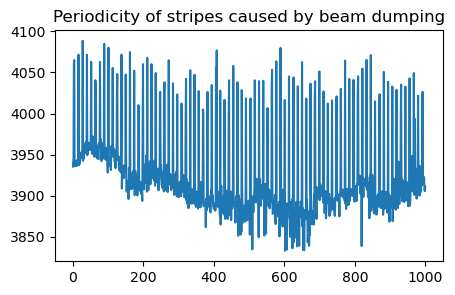

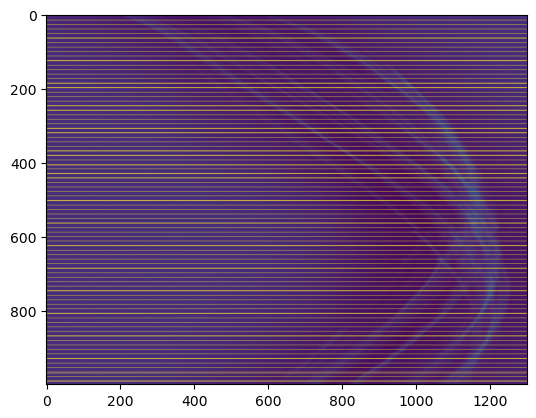

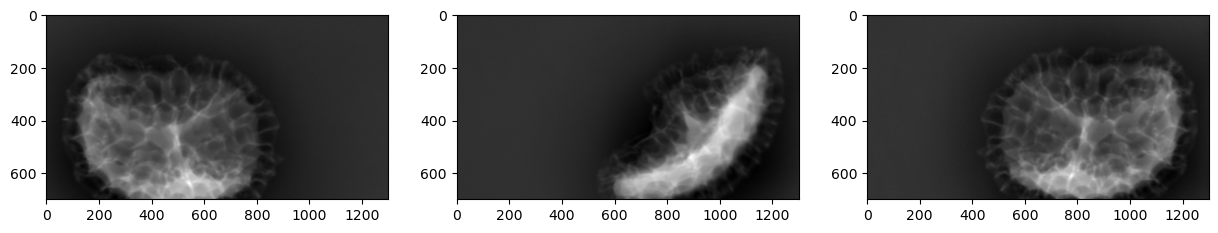

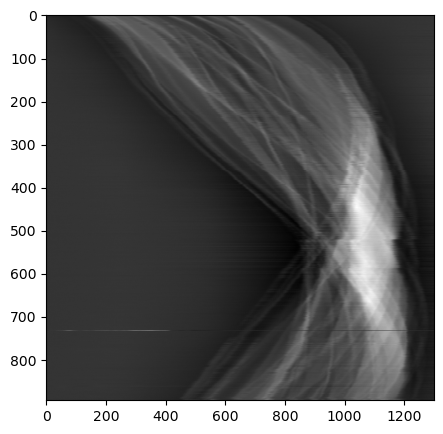

Text(0.5, 1.0, 'Periodicity of stripes caused by beam dumping (after correction)')

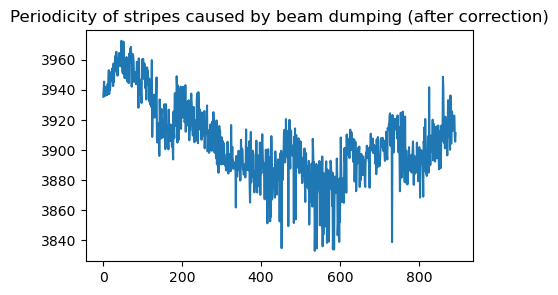

In [11]:
# show an example of the stripes caused by the beam dumping
#for i in range(projections_crop.shape[0]):
#    projections_crop[i,:,:] = projections_crop[i,:,:]/np.mean(projections_crop[i,1:10,1:10])

plt.figure(figsize=[5,3])
plt.plot(np.abs(np.sum(projections_crop[:,projections_crop.shape[1]//2,:],axis = 1)))
plt.title('Periodicity of stripes caused by beam dumping')

# remove stripes
projections_reduced, angles_reduced, good_projs = remove_stripes_oriol(projections_crop, angles, threshold=0.4)

# this will just show the new sinogram with 0s where we have removed the original projections
# It allows us to visually assess how many projections we're removing
sino_number = 150
new_sinogram = np.zeros_like(projections_crop[:,sino_number,:])
new_sinogram[good_projs[0],:] = projections_reduced[:,sino_number,:]
plt.figure()
plt.imshow(new_sinogram)

# plot after fixing stripes
utils.plot_3_projections(projections_reduced)
utils.plot_sinogram(projections_reduced)

plt.figure(figsize=[5,3])
plt.plot(np.abs(np.sum(projections_reduced[:,projections_reduced.shape[1]//2,:],axis = 1)))
plt.title('Periodicity of stripes caused by beam dumping (after correction)')

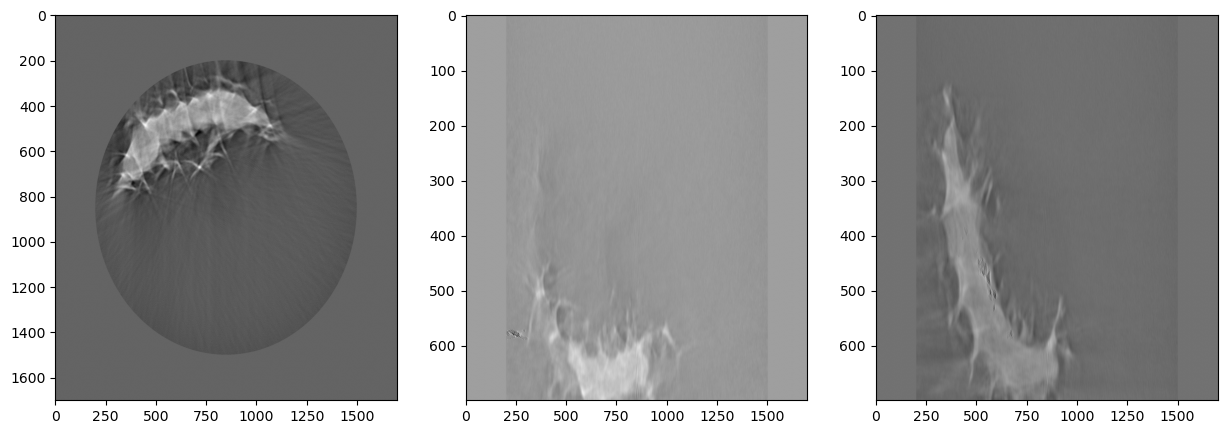

In [14]:
# reconstruct now
volume_gridrec_reduced = get_volume(projections_reduced, angles_reduced, centre=None, pad=200, algorithm='GRIDREC', iterations=1)
utils.plot_volume(volume_gridrec_reduced)

## Functions

In [22]:
# This works by first reconstructing a 3D volume, then reprojecting it with ASTRA into projections
def get_reprojections(projections, angles, centre, pad, algorithm='GRIDREC', iterations=1):
    volume = get_volume(projections, angles, centre, pad, algorithm=algorithm, iterations=iterations)
    if pad > 0:
        reprojections = utils.get_reprojections(volume, angles)[:,:,pad:-pad]
    else:
        reprojections = utils.get_reprojections(volume, angles)[:,:,:]
    return reprojections

In [23]:
def sin_func(x, a, w, b, c):
    return a * np.sin(w*x + b) + c

def fit_com_to_sin(projections,angles,blur_filter = 2):
    import matplotlib.pyplot as plt
    #plt.figure()
    
    projections -= np.amin(projections)
    summed = np.sum(projections[:,:,:],1)
    
    com = np.zeros([2,projections.shape[0]])
    shifts = np.zeros([2,projections.shape[0]])
    for i in range(projections.shape[0]):
        com[:,i] = utils.ndimage.measurements.center_of_mass(summed[i,:])
    
    com_min = np.min(com[1,:])
    com_max = np.max(com[1,:])
    com_range = com_max - com_min
    com_mid = com_min + com_range//2
    
    params, params_covariance = optimize.curve_fit(sin_func, angles, com[1,:], p0=[com_range, 1, 0, com_mid])
    ideal = sin_func(angles_reduced, params[0], params[1], params[2], params[3])
    
    #ideal = (np.cos(angles)*com_range) + com_mid
    
    shifts[1,:] = ideal[:] - com[1,:]
    shifts[1,:] = shifts[1,:] - shifts[1,0]
    #shifts[1,:] = shifts[1,:]*overall_shift/np.max(abs(shifts[1,:]))
    #shifts[1,:] = shifts[1,:]#*overall_shift/(abs(shifts[1,-1]))

    #print("shifts[-1,:] ", shifts[-1,:])
    
    shifts[1,:] = scipy.ndimage.gaussian_filter1d(shifts[1,:],blur_filter)

    plt.figure()
    plt.plot(com[1,:],'bo')
    plt.plot(ideal)
    plt.plot(shifts[1,:],'r+')
    #plt.legend(handles=['com','ideal','shifts'])

    projections_out = apply_reprojection_shifts(projections, shifts, pad=1)
    return projections_out, shifts

def calculate_com_projs(projections):
    #plt.figure()
    
    projections -= np.amin(projections)
    summed = np.sum(projections[:,:,:],1)
    
    com = np.zeros([2,projections.shape[0]])
    shifts = np.zeros([2,projections.shape[0]])
    for i in range(projections.shape[0]):
        com[:,i] = utils.ndimage.measurements.center_of_mass(summed[i:i+1,:])
    
    return com

def calculate_com_projs_oriol(projections):
    #plt.figure()
    
    projections -= np.amin(projections)
    summed = np.sum(projections[:,:,:],1)
    
    com = np.zeros([2,projections.shape[0]])
    shifts = np.zeros([2,projections.shape[0]])
    for i in range(projections.shape[0]):
        com[:,i] = utils.ndimage.measurements.center_of_mass((summed[i:i+1,:]))
    
    return com

In [24]:
from scipy import signal

def xcor(in1, in2):
    xcor = signal.correlate(in1, in2, mode='same')
    shift = np.argmax(xcor)-(xcor.shape[0]/2)
    return shift, xcor

def get_y_shifts(projections):
    proj_sum = np.sum(projections,2)
    shifts = np.zeros(projections.shape[0])
    xcor_ar = np.zeros_like(proj_sum)
    a = np.gradient(proj_sum[0,:])
    for i in range(projections.shape[0]):
        b = np.gradient(proj_sum[i,:])
        shifts[i], xcor_ar[i,:] = xcor(a,b) #
    return shifts

def apply_y_shifts(projections, trans):
    for i in range(projections.shape[0]):
        shift = int(trans[i])
        projections[i,:,:] = np.roll(projections[i,:,:],shift, axis=0)
    return projections

def projection_align_vertical(projections):
    y_trans = get_y_shifts(projections)
    projections = apply_y_shifts(projections, y_trans)

    min_trans = int(np.floor(np.amin(y_trans)))
    max_trans = int(np.ceil(np.amax(y_trans)))

    if min_trans < 0:
        y_to = min_trans
    else:
        y_to = -1
    
    if max_trans > 0:
        y_from = max_trans
    else:
        y_from = 0

    print("y_from", y_from)
    print("y_to", y_to)

    projections = projections[:,y_from:y_to,:]
    return projections

In [26]:
# This function gives the shifts between projections and reprojections in terms of x and y
def get_reprojection_shifts(projections, reprojections, sub_sample=1, sigma=[4,20]):
    shifts = np.zeros([2, projections.shape[0]], dtype = np.float32)
    
    border = 20
    
    sig_high = sigma[1]/sub_sample
    sig_low = sigma[0]/sub_sample
    
    projections = projections[:,::sub_sample,border:-border:sub_sample]
    reprojections = reprojections[:,::sub_sample,border:-border:sub_sample]
    
#     projections = blur(projections, sig_low) - blur(projections, sig_high)
#     reprojections = blur(reprojections, sig_low) - blur(reprojections, sig_high)
    
#     utils.plot_3_projections(projections)
#     utils.plot_sinogram(projections)
#     utils.plot_3_projections(reprojections)
#     utils.plot_sinogram(reprojections)
    
    for i in range(projections.shape[0]):
        image_a = projections[i]
        image_b = reprojections[i]

        if i == 0:
            plt.figure()
            plt.subplot(1,2,1); plt.imshow(image_a)
            plt.subplot(1,2,2); plt.imshow(image_b)
            plt.show()
        
        shift, error, diffphase = register_translation(image_a, image_b)
        
        # print("frame_shift:", shift)
        
        shifts[0,i] = shift[0]
        shifts[1,i] = shift[1]
    shifts *= sub_sample
    return shifts

# This function gives the shifts between projections and reprojections in terms of x and y
def get_reprojection_shifts_com(projections, reprojections, sub_sample=1, sigma=[4,20]):
    shifts = np.zeros([1, projections.shape[0]], dtype = np.float32)
    
    border = 20
    
    sig_high = sigma[1]/sub_sample
    sig_low = sigma[0]/sub_sample
    
    projections = projections[:,::sub_sample,border:-border:sub_sample]
    reprojections = reprojections[:,::sub_sample,border:-border:sub_sample]
    
    for i in range(projections.shape[0]):
        image_a = projections[i]
        image_b = reprojections[i]

        if i == 0:
            plt.figure()
            plt.subplot(1,2,1); plt.imshow(image_a)
            plt.subplot(1,2,2); plt.imshow(image_b)
            plt.show()
        
        #shift, error, diffphase = register_translation(image_a, image_b)
        
        for i in range(projections.shape[0]):
            a = np.sum(image_a,0)
            b = np.sum(image_b,0)

            coma = utils.ndimage.measurements.center_of_mass(a)
            comb = utils.ndimage.measurements.center_of_mass(b)
            
            shifts[0,i] = coma[0]-comb[0]
            
        # print("frame_shift:", shift)
        
        #shifts[0,i] = shift[0]
        #shifts[1,i] = shift[1]
    #shifts *= sub_sample
    return shifts

# This function uses the shifts calculated before to "move" the projections
def apply_reprojection_shifts(projections_in, shifts, pad=0):
    print("apply_reprojection_shifts")
    projections_out = np.zeros_like(projections_in)
    projections_pad = np.copy(utils.pad(projections_in, (pad,0)))
    shifts = np.round(shifts).astype(np.int32)
    
#     print("projections_in.shape", projections_in.shape)
#     print("projections_out.shape", projections_out.shape)
#     print("projections.shape", projections.shape)

    for i in range(projections_in.shape[0]):
#         print("Applying shift [%d,%d] to projection %d" %(shifts[0,i], shifts[1,i], i))
        projections_out[i] = np.roll(projections_pad[i], -1*shifts[0,i], axis=0)[:,pad:-pad]
        projections_out[i] = np.roll(projections_pad[i], -1*shifts[1,i], axis=1)[:,pad:-pad]

        #if i == 0:
        #    plt.figure()
        #    plt.imshow(projections_out[i])
        #    plt.show()
    
#     min_trans_x = int(np.floor(np.amin(shifts[1,:])))
#     max_trans_x = int(np.ceil(np.amax(shifts[1,:])))
#     if min_trans_x < 0:
#         x_to = min_trans_x
#     else:
#         x_to = -1
    
#     if max_trans_x > 0:
#         x_from = max_trans_x
#     else:
#         x_from = 0
        
        
#     min_trans_y = int(np.floor(np.amin(shifts[0,:])))
#     max_trans_y = int(np.ceil(np.amax(shifts[0,:])))
#     if min_trans_y < 0:
#         y_to = min_trans_y
#     else:
#         y_to = -1
    
#     if max_trans_y > 0:
#         y_from = max_trans_y
#     else:
#         y_from = 0

#     projections_out = projections_out[:,y_from:y_to,x_from:x_to]
    
    return projections_out

## In-depth alignment

y_from 34
y_to -1
Before correction, shape:  (894, 700, 1300)
After correction, shape:  (894, 665, 1300)


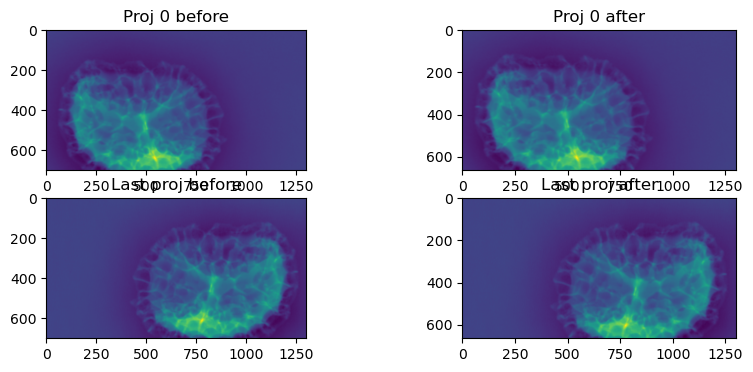

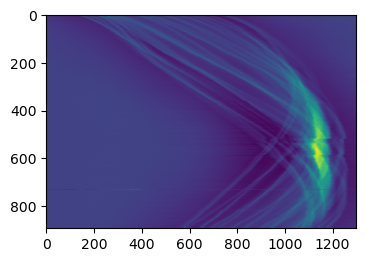

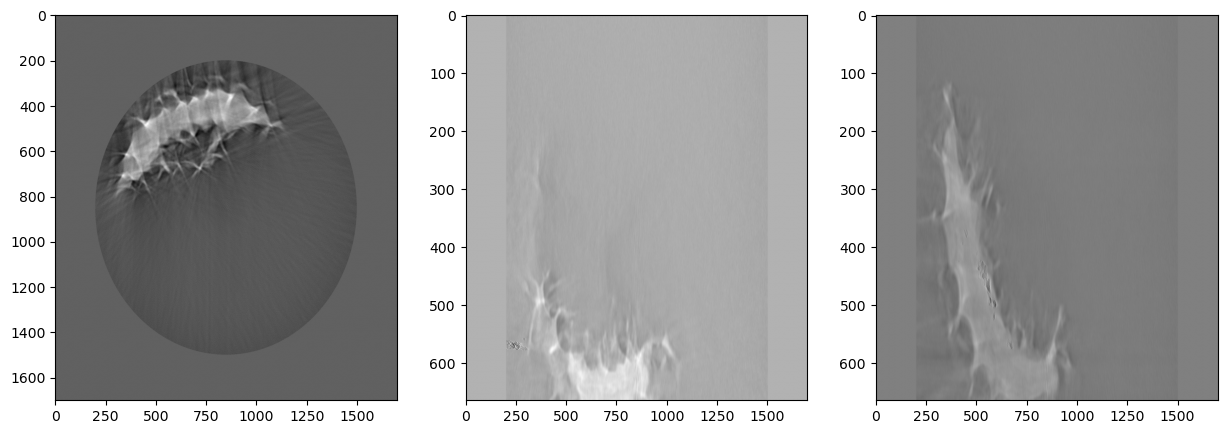

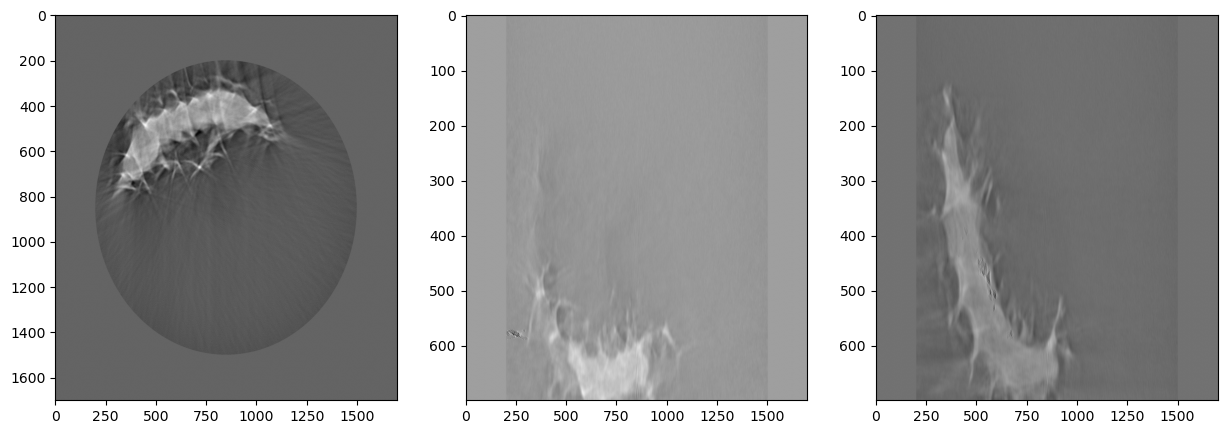

In [27]:
# Do vertical motion correction

projections_recon_align = np.copy(projections_reduced) # copy projections reduced so that we don't lose them

projections_aligned_vert = projection_align_vertical(projections_recon_align) # do the vertical alignment 

print('Before correction, shape: ', projections_reduced.shape)
print('After correction, shape: ', projections_aligned_vert.shape)

# plot first and last projections before and after correction
plt.figure(figsize=[10,4])
plt.subplot(2,2,1), plt.imshow(projections_reduced[0,:,:]), plt.title('Proj 0 before') # before
plt.subplot(2,2,2), plt.imshow(projections_aligned_vert[0,:,:]), plt.title('Proj 0 after')# after
plt.subplot(2,2,3), plt.imshow(projections_reduced[-1,:,:]), plt.title('Last proj before')# before
plt.subplot(2,2,4), plt.imshow(projections_aligned_vert[-1,:,:]), plt.title('Last proj after')# after

plt.figure(figsize=[4,4])
plt.imshow(projections_aligned_vert[:,200,:])

# reconstruct now
volume_gridrec_vert = get_volume(projections_aligned_vert, angles_reduced, centre=None, pad=200, algorithm='GRIDREC', iterations=1)
utils.plot_volume(volume_gridrec_vert)
utils.plot_volume(volume_gridrec_reduced)

(894, 665, 1300)
(894, 665, 1700)


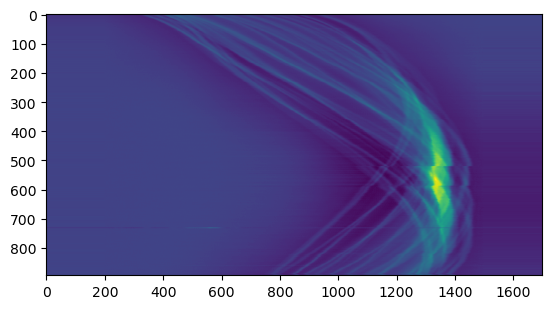

In [21]:
# Pad the projections because we'll start using np.roll
print(projections_aligned_vert.shape)
projections_aligned_vert = np.pad(projections_aligned_vert, ((0,0),(0,0),(200,200)), mode='edge') #(projections_aligned_vert, (100,0)) 
plt.imshow(projections_aligned_vert[:,200,:])
print(projections_aligned_vert.shape)

In [21]:
# Manual trial-and-error step to fix any large misalignments
proj1 = 500
proj2 = 550
x1 = 800
x2 = 1400
subset = projections_aligned_vert[proj1:proj2,projections_aligned_vert.shape[1]//2,x1:x2]

plt.figure(figsize=[10,10])
plt.imshow(subset)

NameError: name 'projections_aligned_vert' is not defined

In [20]:
# Manual trial-and-error step to fix any large misalignments
misaligned_proj = 21 # with respect to proj1
rough_correction = 10 # pixels
error = 5 # pixels

subset = projections_aligned_vert[proj1:proj2,projections_aligned_vert.shape[1]//2,:]
plt.figure(figsize=[10,10])
plt.imshow(subset[:,x1:x2])
plt.title('No correction')

subset1 = np.copy(subset)
subset1[misaligned_proj:proj2-proj1,:] = np.roll(subset[misaligned_proj:proj2-proj1,:],rough_correction - error,axis=1)
plt.figure(figsize=[10,10])
plt.imshow(subset1[:,x1:x2])
plt.title('Correction of '+str(rough_correction - error))

subset2 = np.copy(subset)
subset2[misaligned_proj:proj2-proj1,:] = np.roll(subset[misaligned_proj:proj2-proj1,:],rough_correction,axis=1)
plt.figure(figsize=[10,10])
plt.imshow(subset2[:,x1:x2])
plt.title('Correction of '+str(rough_correction))

subset3 = np.copy(subset)
subset3[misaligned_proj:proj2-proj1,:] = np.roll(subset[misaligned_proj:proj2-proj1,:],rough_correction + error,axis=1)
plt.figure(figsize=[10,10])
plt.imshow(subset3[:,x1:x2])
plt.title('Correction of '+str(rough_correction + error))

NameError: name 'projections_aligned_vert' is not defined

(<Axes: title={'center': 'Uncorrected'}>,
 Text(0.5, 1.0, 'Uncorrected'))

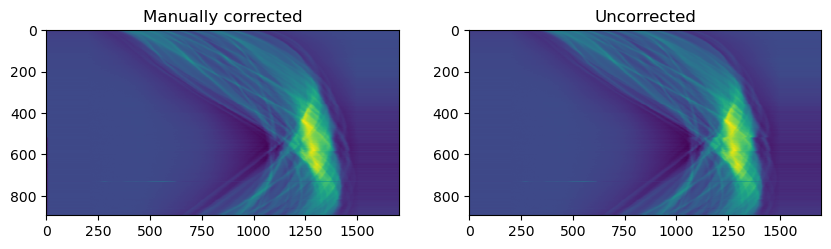

In [24]:
# Manual trial-and-error step to fix any large misalignments
correction_value = 10

misaligned_projection = proj1+misaligned_proj

projections_aligned_vert_fix = np.copy(projections_aligned_vert)
projections_aligned_vert_fix[misaligned_projection:-1,:,:] = np.roll(projections_aligned_vert[misaligned_projection:-1,:,:],correction_value,axis = 2)

plt.figure(figsize=[10,10])
plt.subplot(1,2,1), plt.imshow(projections_aligned_vert_fix[:,projections_aligned_vert_fix.shape[1]//2,:]), plt.title('Manually corrected')
plt.subplot(1,2,2), plt.imshow(projections_aligned_vert[:,projections_aligned_vert.shape[1]//2,:]), plt.title('Uncorrected')

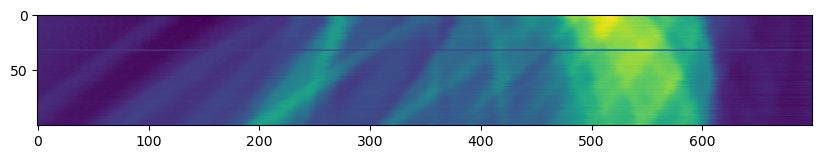

In [25]:
# do any other manual corrections that you might need e.g. by copy-pasting the cells from above

# Manual trial-and-error step to fix any large misalignments (part 2)
proj1 = 700
proj2 = 800
x1 = 800
x2 = 1500
subset = projections_aligned_vert[proj1:proj2,projections_aligned_vert.shape[1]//2,x1:x2]

plt.figure(figsize=[10,10])
plt.imshow(subset)

Text(0.5, 1.0, 'Correction of 800')

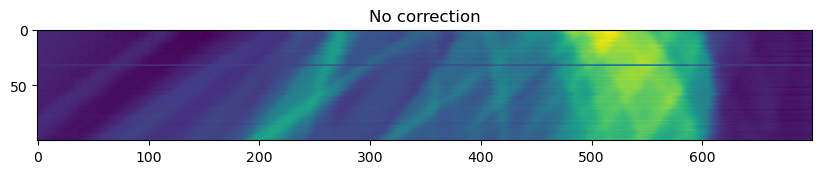

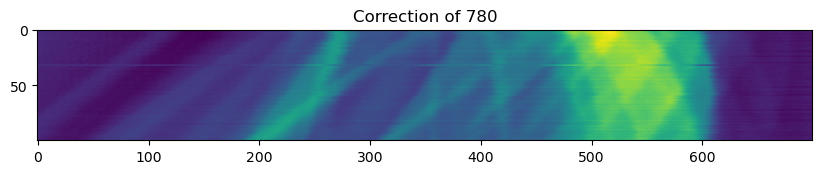

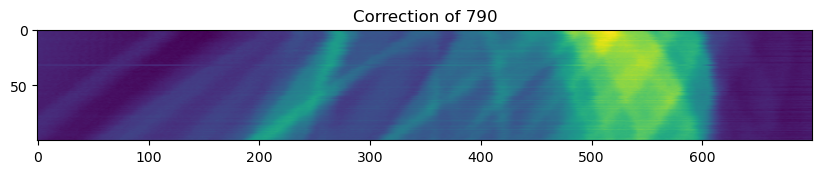

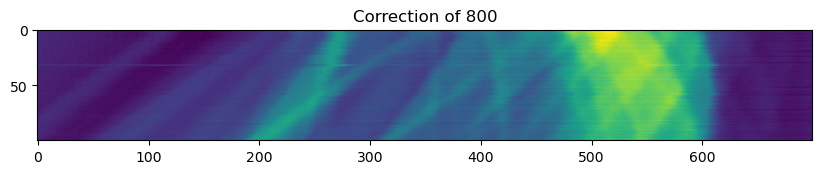

In [26]:
# Manual trial-and-error step to fix any large misalignments
misaligned_proj = 32 # with respect to proj1
rough_correction = 790 # pixels
error = 10 # pixels

subset = projections_aligned_vert[proj1:proj2,projections_aligned_vert.shape[1]//2,:]
plt.figure(figsize=[10,10])
plt.imshow(subset[:,x1:x2])
plt.title('No correction')

subset1 = np.copy(subset)
subset1[misaligned_proj,:] = np.roll(subset[misaligned_proj,:],rough_correction - error,axis=0)
plt.figure(figsize=[10,10])
plt.imshow(subset1[:,x1:x2])
plt.title('Correction of '+str(rough_correction - error))

subset2 = np.copy(subset)
subset2[misaligned_proj,:] = np.roll(subset[misaligned_proj,:],rough_correction,axis=0)
plt.figure(figsize=[10,10])
plt.imshow(subset2[:,x1:x2])
plt.title('Correction of '+str(rough_correction))

subset3 = np.copy(subset)
subset3[misaligned_proj,:] = np.roll(subset[misaligned_proj,:],rough_correction + error,axis=0)
plt.figure(figsize=[10,10])
plt.imshow(subset3[:,x1:x2])
plt.title('Correction of '+str(rough_correction + error))

(<Axes: title={'center': 'Uncorrected'}>,
 Text(0.5, 1.0, 'Uncorrected'))

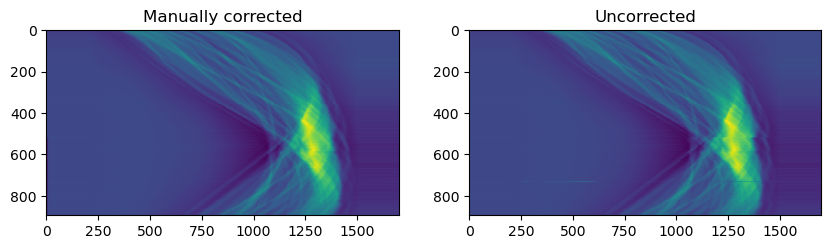

In [27]:
# Manual trial-and-error step to fix any large misalignments
correction_value = 790

misaligned_projection = proj1+misaligned_proj

projections_aligned_vert_fix2 = np.copy(projections_aligned_vert_fix)
projections_aligned_vert_fix2[misaligned_projection,:,:] = np.roll(projections_aligned_vert_fix[misaligned_projection,:,:],correction_value,axis = 1)

plt.figure(figsize=[10,10])
plt.subplot(1,2,1), plt.imshow(projections_aligned_vert_fix2[:,projections_aligned_vert_fix2.shape[1]//2,:]), plt.title('Manually corrected')
plt.subplot(1,2,2), plt.imshow(projections_aligned_vert[:,projections_aligned_vert_fix.shape[1]//2,:]), plt.title('Uncorrected')

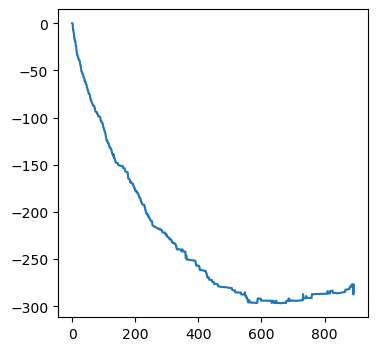

In [31]:
# Alignment in the x-direction with cross-correlation

quick_xcorrelation = np.zeros((2,projections_aligned_vert_fix2.shape[0]))
                              
for gag in range(1,projections_aligned_vert_fix2.shape[0]):
    a = (projections_aligned_vert_fix2[gag-1,:,:])#np.sum(projections[i,50:-50,250:750],0)
    b = (projections_aligned_vert_fix2[gag,:,:])#np.sum(reprojections2[i,50:-50,250:750],0)
    
    shift_ab = register_translation(a,b,upsample_factor=100)
    quick_xcorrelation[1,gag] = shift_ab[0][1] + quick_xcorrelation[1,gag-1]

plt.figure(figsize=[4,4])
plt.plot(quick_xcorrelation[1,:])

apply_reprojection_shifts


(<Figure size 640x480 with 1 Axes>,
 <matplotlib.image.AxesImage at 0x7f76781ac290>)

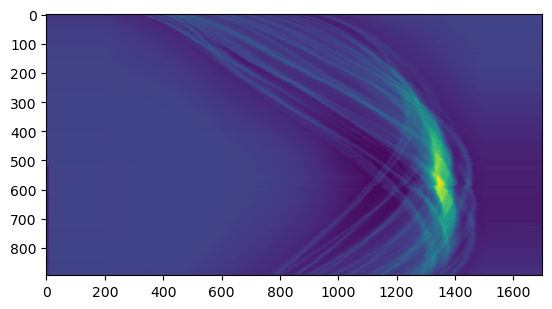

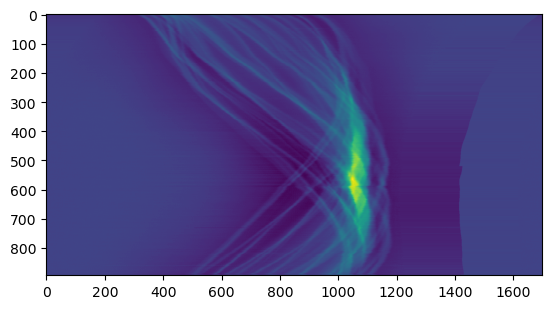

In [34]:
# apply the shifts from cross-correlation to the projections
import scipy
correction_rough = apply_reprojection_shifts(projections_aligned_vert_fix2, -scipy.ndimage.gaussian_filter1d(quick_xcorrelation,10), pad=1)
plt.imshow(projections_aligned_vert_fix2[:,200,:])
plt.figure(),plt.imshow(correction_rough[:,200,:])


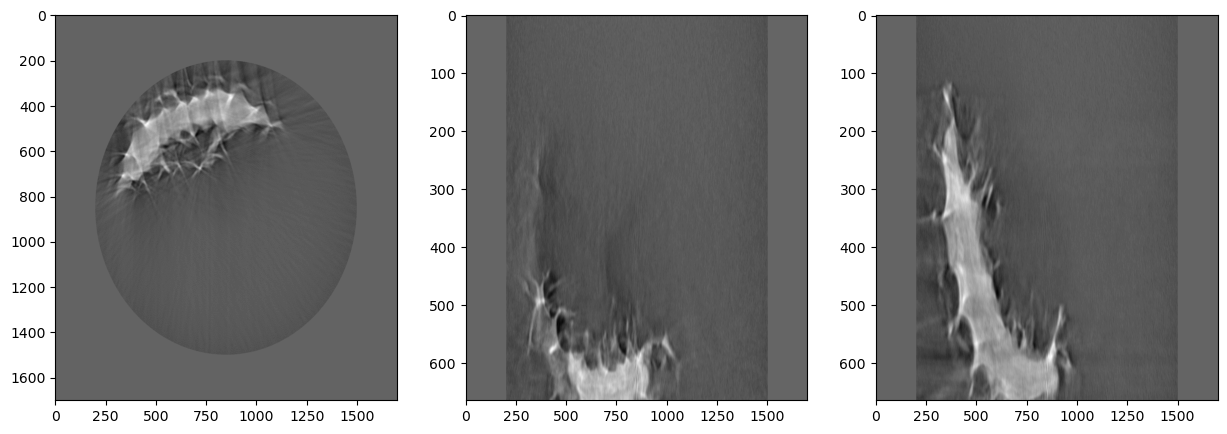

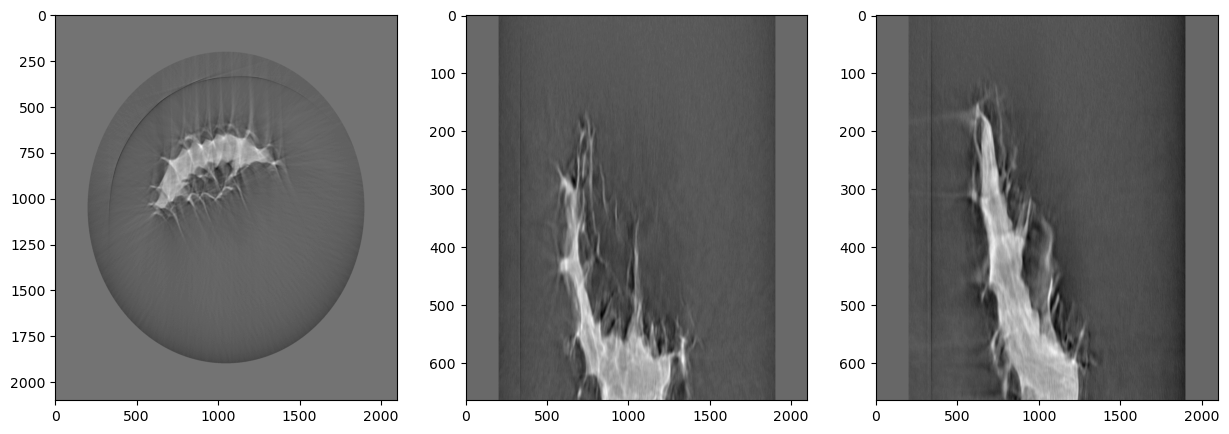

In [35]:
volume_gridrec_aligned = get_volume(correction_rough, angles_reduced, centre=None, pad=200, algorithm='GRIDREC', iterations=1)

# Compare reconstructions before and after alignment
utils.plot_volume(volume_gridrec_vert[:,:,:])
utils.plot_volume(volume_gridrec_aligned[:,:,:])

apply_reprojection_shifts


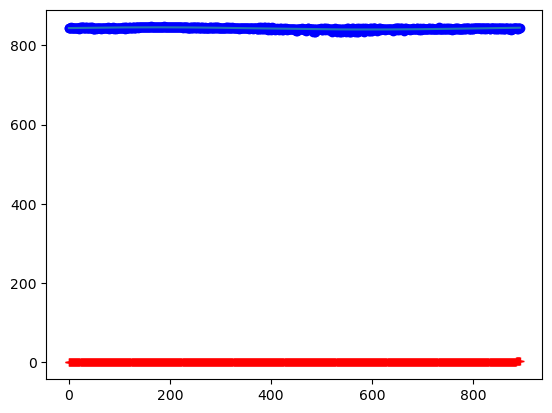

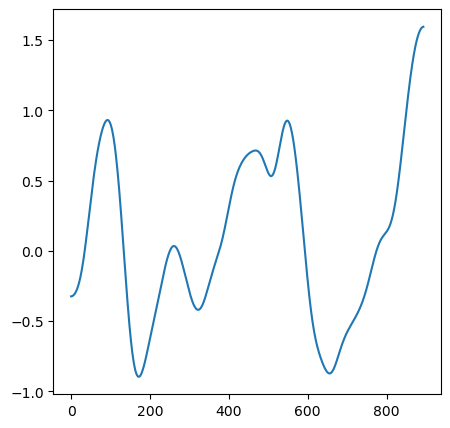

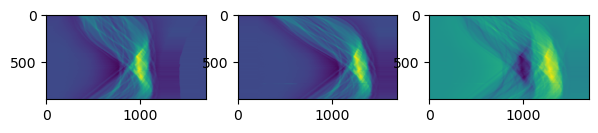

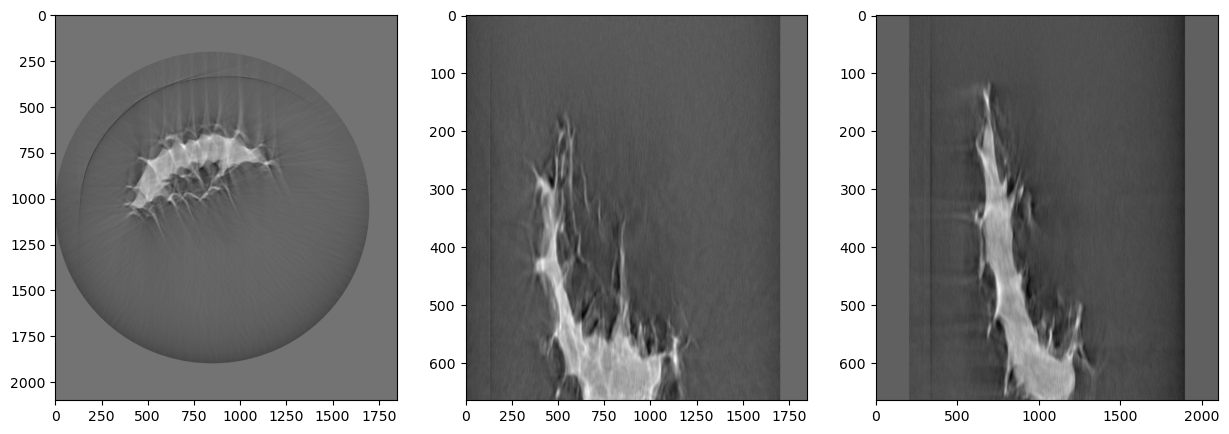

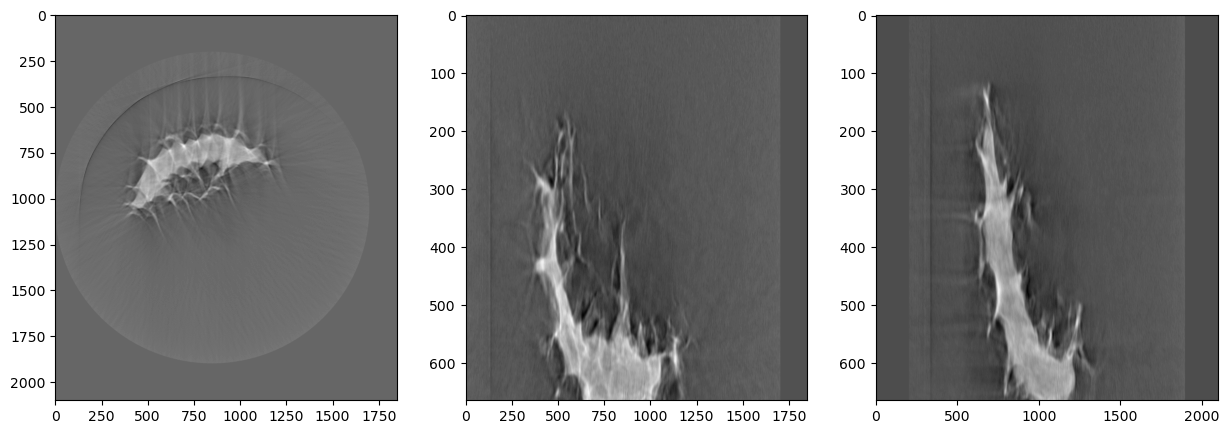

In [36]:
# calculate the rough overall translation between 0 and 180 degrees by using cross-correlation between projection 1 
# and the last projection, flipped
# shifty = register_translation(projections_aligned_vert_fix[0,:,:],np.fliplr(projections_aligned_vert_fix[-1,:,:]),upsample_factor=100)
# print('The shift between 0 deg and 180 deg is roughly ' + str(shifty[0][0]) + ' in the vertical direction and '
#                     + str(shifty[0][1]) + ' in the horizontal direction.')

# Calculate the centre of mass (COM) for each projection of the scan. The COM should follow a sinusoidal motion.
# Then fit a sinusoid and shift the projections as required to fit that sinusoid. 
projections_fitted, shifts_fitted = fit_com_to_sin(correction_rough,angles_reduced, blur_filter = 20)

plt.figure(figsize=[5,5])
plt.plot(shifts_fitted[1,:])

plt.figure(figsize=[7,5])
ax1 = plt.subplot(1,3,1), plt.imshow(projections_fitted[:,int(projections_fitted.shape[1]/2),:])
ax2 = plt.subplot(1,3,2), plt.imshow(projections_aligned_vert_fix[:,int(projections_aligned_vert_fix.shape[1]/2),:])
ax3 = plt.subplot(1,3,3), plt.imshow(projections_aligned_vert_fix[:,int(projections_aligned_vert_fix.shape[1]/2),:]-projections_fitted[:,int(projections_fitted.shape[1]/2),:])

# Reconstruct 
volume_gridrec_aligned2 = get_volume(projections_fitted, angles_reduced, centre=None, pad=200, algorithm='GRIDREC', iterations=1)

# Compare reconstructions before and after alignment
utils.plot_volume(volume_gridrec_aligned[:,:,200:-50])
utils.plot_volume(volume_gridrec_aligned2[:,:,200:-50])

## Save the results

In [37]:
import os 
os.getcwd()

'/home/zvm34551/Ptychography_Diamond'

In [235]:
# save the volume -- I haven't actually tested this
import h5py
f = h5py.File('/dls/staging/dls/i13-1/data/2024/mg34773-2/processing/tomo/386068/tomo_gridrec_aligned.h5','w')
f.create_dataset('data', data=volume_gridrec_aligned)
f.close()

## Work in progress

In [13]:
# Applying gaussian filter to stack of images
def blur(image_stack, sigma=1):
    return gaussian_filter(image_stack, (0,sigma,sigma))

In [16]:
def blur_edges(prj, low=0, high=0.8):
    """
    Blurs the edge of the projection images.

    Parameters
    ----------
    prj : ndarray
        3D stack of projection images. The first dimension
        is projection axis, second and third dimensions are
        the x- and y-axes of the projection image, respectively.
    low : scalar, optional
        Min ratio of the blurring frame to the image size.
    high : scalar, optional
        Max ratio of the blurring frame to the image size.

    Returns
    -------
    ndarray
        Edge-blurred 3D stack of projection images.
    """
    _prj = prj.copy()
    dx, dy, dz = _prj.shape
    rows, cols = np.mgrid[:dy, :dz]
    rad = np.sqrt((rows - dy / 2)**2 + (cols - dz / 2)**2)
    mask = np.zeros((dy, dz))
    rmin, rmax = low * rad.max(), high * rad.max()
    mask[rad < rmin] = 1
    mask[rad > rmax] = 0
    zone = np.logical_and(rad >= rmin, rad <= rmax)
    mask[zone] = (rmax - rad[zone]) / (rmax - rmin)
    feathered = np.empty((dy, dz), dtype=np.uint8)
    _prj *= 1-mask
    return _prj

In [17]:
# import matplotlib.pyplot as plt
import scipy
def align_joint(projections_original, angles, centre=None, pad=0, iters = 1, window_crop=[50,-50,50,-50], subsample=1, algorithm='GRIDREC', iterations=5, sigma=[4,20]):    
    if centre == None:
        centre = utils.findCentre(projections_original)

    projections = np.copy(projections_original)
    global_shifts = np.zeros([2, projections.shape[0]])

    max_global_shift = [(window_crop[0] - window_crop[1])//2, (window_crop[2] - window_crop[3])//2]
    print("max_global_shift:", max_global_shift)

    import matplotlib.pyplot as plt
    
    for iteration in range(iters):
        print("Generating reprojections")
        projections_slices = projections[:,window_crop[0]:window_crop[1],:]
        projections_window = projections_slices[:,:,window_crop[2]:window_crop[3]]

        print("Input centre of rotation:", centre)
        reprojections = get_reprojections(projections_slices, angles, centre=centre, pad=pad, algorithm=algorithm, iterations=iterations)
        reprojections_window = reprojections[:,:,window_crop[2]:window_crop[3]]
        print("Calculating shifts")
        
        plot_sinogram_sum_com(projections_window, angles)
        plot_sinogram_sum_com(reprojections_window, angles)
        
        projections_blurred = blur_edges(projections_window, low=0.8, high=0)
        reprojections_blurred = blur_edges(reprojections_window, low=0.8, high=0)
        
        utils.plot_3_projections(projections_blurred)
        utils.plot_3_projections(reprojections_blurred)
        
        shifts = get_reprojection_shifts(projections_blurred, reprojections_blurred, subsample, sigma) * -1

        print("new centre of rotation =", centre)

        plt.figure()
        plt.plot(global_shifts[1])
        global_shifts[:] = global_shifts + shifts
        global_shifts[0,global_shifts[0]>max_global_shift[0]] = max_global_shift[0]
        global_shifts[1,global_shifts[1]>max_global_shift[1]] = max_global_shift[1]

        plt.plot(global_shifts[1])
        
        
        print("Correcting projections")
        projections[:] = apply_reprojection_shifts(projections_original, global_shifts, pad)
        
        utils.plot_sinogram(projections)
        #plot_sinogram_sum_com(projections[:,:50,:], angles)
        
        rmse = np.sqrt(np.mean(np.abs(projections[:,window_crop[0]:window_crop[1],:] - reprojections)**2))
        print("Error (RMSE):", rmse)
    
    return projections, centre
    
     # shifts[shifts>30] = 30
        # shifts[shifts<-30] = -30

        # plt.figure()
        # plt.plot(shifts[0,:])
        # plt.figure()
        # plt.plot(shifts[1,:])
        
        # print("shifts shape", shifts.shape)
        
        # centre_shift = np.mean(shifts, axis=1)
        
        
#         print("centre_shift", centre_shift)

        # shifts[0,:] -= centre_shift[0]
        # shifts[1,:] -= centre_shift[1]


        
        # print("Maximum shift Y:", np.max((shifts[0,:])))
        # print("Maximum shift X:", np.max((shifts[1,:])))
        # print("Minimum shift Y:", np.min((shifts[0,:])))
        # print("Minimum shift X:", np.min((shifts[1,:])))
        
        
        
#         shifts[1,:] = scipy.ndimage.gaussian_filter1d(shifts[1,:], 20)
        
        # centre -= centre_shift[1]

In [20]:
def plot_sinogram_sum_com(projections,angles):
    plt.figure(figsize=[5,5])
    projections -= np.amin(projections)
    summed = np.sum(projections[:,:,:],1)
    plt.subplot(3,1,1)
    plt.imshow(summed)
    com = np.zeros([2,projections.shape[0]])
    for i in range(projections.shape[0]):
        com[:,i] = utils.ndimage.measurements.center_of_mass(summed[i:i+1,:])
    plt.subplot(3,1,2)
    plt.plot(np.cos(angles))
    plt.subplot(3,1,3)
    plt.plot(com[1,:])
    diff = com[1,:] - np.mean(com[1,:])
    #plt.plot(diff)
    plt.show()

In [18]:
# import matplotlib.pyplot as plt
import scipy
def align_joint_oriol(projections_original, angles, centre=None, pad=0, iters = 1, window_crop=[50,-50,50,-50], subsample=1, algorithm='GRIDREC', iterations=5, sigma=[4,20]):    
    if centre == None:
        centre = utils.findCentre(projections_original)
        
    print('The centre of rotation is: ', str(centre))
    
    projections = np.copy(projections_original) # copy so that we don't lose them
    global_shifts = np.zeros([2, projections.shape[0]])

    max_global_shift = [(window_crop[0] - window_crop[1])//2, (window_crop[2] - window_crop[3])//2]
    print("max_global_shift:", max_global_shift) # related to the size of the window crop

    print('1. Correct through cross correlation')
    
    reprojections = get_reprojections(projections, angles_reduced, centre=centre, pad=100, algorithm='GRIDREC', iterations=2)
    
    plt.figure()
    plt.title('1. Correct through cross correlation')
    plt.subplot(1,2,1), plt.imshow(projections[800,:,:]),
    plt.subplot(1,2,2), plt.imshow(reprojections[800,:,:])
    
    shifts = np.zeros(projections_test.shape[0])
    for i in range(projections_test.shape[0]):
            image_a = projections[i,:,:]
            image_b = reprojections[i,:,:]
            shifty2 = register_translation(image_a,image_b,upsample_factor=10)
            shifts[i] = shifty2[0][1]
    
    mean_displacement = np.mean(shifts)     
    print('    The mean displacement between proj and reproj according to cross-correlation is: ' + str(mean_displacement))
    
    correct_proj_displacement = np.zeros_like(projections)
    correct_proj_displacement[:,:,:] = np.roll(projections[:,:,:], -1*int(mean_displacement), axis=2)
    
    plt.figure()
    plt.title('1. After correction through cross correlation')
    plt.subplot(1,2,1),plt.imshow(projections[800,:,:])
    plt.subplot(1,2,2),plt.imshow(correct_proj_displacement[800,:,:])

    centre = utils.findCentre(correct_proj_displacement)
    print('    The new centre of rotation is: ', str(centre))
    
    print('2. Start iterative process (annealing)')
    iterated_projections = np.copy(correct_proj_displacement)
    
    for iteration in range(iters):
        print("2.1. Generate the reprojections")
        
        # crop projections
        projections_window = iterated_projections[:,:,window_crop[2]:window_crop[3]]

        # create the reprojections
        reprojections2 = get_reprojections(projections_window, angles, centre=centre, pad=pad, algorithm=algorithm, iterations=iterations)
        reprojections_window = reprojections2[:,:,window_crop[2]:window_crop[3]]
        print('    Reprojections have been created.')
        
        #plot_sinogram_sum_com(projections_window, angles)
        #plot_sinogram_sum_com(reprojections_window, angles)

        ## blur projections; this is mostly needed when you do cross-correlation
        #projections_blurred = blur_edges(projections_window, low=0.8, high=0)
        #reprojections_blurred = blur_edges(reprojections_window, low=0.8, high=0)
        
        #utils.plot_3_projections(projections_blurred)
        #utils.plot_3_projections(reprojections_blurred)

        print("2.2. Calculate the shifts with centre of mass")

        reprojections2 = get_reprojections(iterated_projections, angles_reduced, centre=centre, pad=100, 
                                           algorithm='GRIDREC', iterations=2)
        
        shifts_com = np.zeros(iterated_projections.shape[0])
        for i in range(projections_test.shape[0]):
                image_a = iterated_projections[i,:,:]
                image_b = reprojections2[i,:,:]
                        
                a = np.sum(image_a,0)
                b = np.sum(image_b,0)
        
                coma = utils.ndimage.measurements.center_of_mass(a)
                comb = utils.ndimage.measurements.center_of_mass(b)
            
                shifts[i] = coma[0]-comb[0]
                
        plt.figure()
        plt.plot(shifts[:])
        
        proj_COM_alignmentNeg = np.zeros_like(iterated_projections)        
        for i in range(correct_proj_displacement.shape[0]):
        #         print("Applying shift [%d,%d] to projection %d" %(shifts[0,i], shifts[1,i], i))
            iterated_projections[i,:,:] = np.roll(iterated_projections[i,:,:], -1*int(shifts[i]), axis=1)
        
        #plt.figure(figsize=[15,10])
        #plt.subplot(4,1,1),plt.imshow(correct_proj_displacement[800,:,200:600])
        #plt.subplot(4,1,2),plt.imshow(reprojections2[800,:,200:600])
        #plt.subplot(4,1,3),plt.imshow(proj_COM_alignmentNeg[800,:,200:600] )
        #plt.subplot(4,1,4),plt.imshow(proj_COM_alignmentPos[800,:,200:600] )
        
        print(utils.ndimage.measurements.center_of_mass(np.sum(iterated_projections[800,:,:],0)))
        print(utils.ndimage.measurements.center_of_mass(np.sum(reprojections2[800,:,:],0)))
        print(int(shifts[800]))
        
        #shifts = get_reprojection_shifts(projections_blurred, reprojections_blurred, subsample, sigma) * -1
        #shifts = get_reprojection_shifts_com(projections_window, reprojections_window, subsample, sigma) * -1
        
        centre = utils.findCentre(iterated_projections)
        print('    The new centre of rotation is: ', str(centre))
    
        #plt.figure()
        #p#lt.plot(shifts)
        #plt.title('Shifts from centre of mass')
        
        #plt.plot(global_shifts[1])
        #global_shifts[:] = global_shifts + shifts
        #global_shifts[0,global_shifts[0]>max_global_shift[0]] = max_global_shift[0]
        #global_shifts[1,global_shifts[1]>max_global_shift[1]] = max_global_shift[1]
        #plt.plot(global_shifts[1])
        
        #print("3. Correct the projections")
        #projections[:] = apply_reprojection_shifts(projections_original, global_shifts, pad)
        
        utils.plot_sinogram(iterated_projections)
        #plot_sinogram_sum_com(projections[:,:50,:], angles)
        
        #rmse = np.sqrt(np.mean(np.abs(projections[:,window_crop[0]:window_crop[1],:] - reprojections)**2))
        #print("Error (RMSE):", rmse)
    
    return iterated_projections, centre

In [22]:
def align_seq(projections_in, pad, subsample=4, iters = 1, window_crop=[0,-1,0,-1]):
    import matplotlib.pyplot as plt
    projections_out = np.copy(projections_in)
    projections_out = utils.pad(projections_out, (pad,0))

    #shifts = utils.get_projection_shifts(blur(projections_out[:,window_crop[0]:window_crop[1],window_crop[2]:window_crop[3]]), subsample)
    shifts = utils.get_projection_shifts((projections_out[:,window_crop[0]:window_crop[1],window_crop[2]:window_crop[3]]), subsample)

    plt.figure(figsize=[5,5])
    plt.plot(shifts[0,:])
    plt.plot(shifts[1,:])
    
    projections_out = utils.apply_projection_shifts(projections_out, -shifts)
    projections_out = projections_out[:,:,pad:-pad]
    
    min_trans_x = int(np.floor(np.amin(shifts[1,:])))
    max_trans_x = int(np.ceil(np.amax(shifts[1,:])))
    if min_trans_x < 0:
        x_to = min_trans_x
    else:
        x_to = -1
    
    if max_trans_x > 0:
        x_from = max_trans_x
    else:
        x_from = 0
        
        
    min_trans_y = int(np.floor(np.amin(shifts[0,:])))
    max_trans_y = int(np.ceil(np.amax(shifts[0,:])))
    if min_trans_y < 0:
        y_to = min_trans_y
    else:
        y_to = -1
    
    if max_trans_y > 0:
        y_from = max_trans_y
    else:
        y_from = 0

    projections_out = projections_out[:,y_from:y_to,x_from:x_to]
    
    return projections_out

In [23]:
def iterative_correction_com(projections,angles_reduced, window_crop=[0,-1,0,-1],iteration_number = 5, 
                             pad=100, blur = 10, direction = -1, algorithm = 'GRIDREC', debug = 1):
    
    keep_projections_safe = np.copy(projections)
    
    # padding the projections is extremely important, because otherwise the rolled values will "confuse" the centre-of-mass calculations
    projections = np.pad(projections, ((0,0),(0,0),(pad,pad)))
    rmse_array = np.zeros((iteration_number,1))
    mean_diff = np.zeros((iteration_number,1))
    std_diff = np.zeros((iteration_number,1))

    global_shifts = np.zeros((2,projections.shape[0],iteration_number))

    for i in range(iteration_number):
        ## need to find a new centre of rotation because we're constantly messing around with projections
        centreNew = utils.findCentre(projections)

        ## we'll be displaying sinograms to assess the correction, so this is just a way to choose which sinogram we display
        sino_number = int(projections.shape[1]/2)
        
        # get reprojections from the latest projections
        # reprojections = get_reprojections(projections, angles_reduced, centre=centreNew, pad=100, algorithm=algorithm, iterations=2)

        # here we calculate the centre-of-mass for each frame for the projections and the reprojections. Top 2 lines are without
        # blurring, bottom 2 are with blurring; comment / uncomment as you please
        com_projections = calculate_com_projs_oriol((projections[:,:,window_crop[2]:window_crop[3]]))

        com_max_proj = np.max(com_projections[1,:])
        com_min_proj = np.min(com_projections[1,:])
        com_range_proj = com_max_proj - com_min_proj
        com_mid_proj = com_min_proj + com_range_proj//2
        
        params, params_covariance = optimize.curve_fit(sin_func, angles_reduced, com_projections[1,:], p0=[com_range_proj, 1, 0, com_mid_proj])
        com_projections_fitted = sin_func(angles_reduced, params[0], params[1], params[2], params[3])
        
        # this makes sure that the first centre-of-mass value is in 0. This is somewhat arbitrary but it helps
        # with plotting and visual aids
        #com_projections[1,:] = com_projections[1,:]-com_projections[1,0]
        #com_projections_fitted = com_projections_fitted-com_projections_fitted[0]

        # calculate the differences between centre-of-mass of projections and centre-of-mass of reprojections
        difference_unblurred = np.zeros([2,projections.shape[0]]) # initialise array
        difference_blurred = np.zeros([2,projections.shape[0]]) # initialise array
        difference_unblurred[1,:] = (com_projections[1,:])-(com_projections_fitted) # here we simply subtract one from the other

        # here we blur the difference to remove some of the high frequency noise (this probably needs improvement)
        difference_blurred[1,:] = scipy.ndimage.gaussian_filter1d(difference_unblurred[1,:],blur) 
        #difference_apply = difference_unblurred-difference_blurred
        #difference_blurred = np.copy(difference_unblurred)
        #difference_blurred -= difference_blurred[1,0] # this line probably needs improvement as well
        
        if debug == 1:
            plt.figure(figsize=[6,3])
            plt.subplot(1,2,1)
            plt.plot(angles_reduced,com_projections[1,:],angles_reduced,com_projections_fitted,'--') 
            plt.title('COM proj')
            plt.legend(["proj","fit proj"])
            plt.subplot(1,2,2)
            plt.plot(angles_reduced,difference_unblurred[1,:],angles_reduced,difference_blurred[1,:])
            plt.title('Difference')
            plt.legend(["shifts","filtered"])
            
        global_shifts[1,:,i] = difference_blurred[1,:]
        
        # apply the shifts (or "difference") to the projections. You may need to try to have the shifts negative or positive. 
        projections = apply_reprojection_shifts(projections,direction*difference_blurred,pad=1)
        #projections = utils.apply_projection_shifts(projections,direction*difference_apply)
        
        # calculate error metric, e.g. rmse
        # rmse_array[i] = np.sqrt(np.mean(np.abs(projections - reprojections)**2))
        rmse_array[i] = np.sqrt(np.mean(np.abs(difference_unblurred[1,:] )**2))
        
        # calculate mean and standard deviation of the difference; this can help us understand the progress of our correction
        mean_diff[i] = np.mean(difference_blurred[1,:])
        std_diff[i] = np.std(difference_blurred[1,:])
        
        print('ITERATION '+str(i+1)+' / '+str(iteration_number)+':')
        print('   - mean value of shifts: '+str(mean_diff[i][0])+' pixels.')
        print('   - standard deviation:   '+str(std_diff[i][0])+' pixels.')
        print('   - error (RMSE):         ', rmse_array[i][0])

        #if debug == 1:
        #    plt.figure(figsize=[10,3])
        #    ax1 = plt.subplot(1,3,1), plt.imshow(projections[:,sino_number,pad:-pad], cmap='gray'), plt.title('Corrected') #plt.colorbar()
        #    ax2 = plt.subplot(1,3,2), plt.imshow(reprojections[:,sino_number,pad:-pad], cmap='gray'), plt.title('Reprojections') #plt.colorbar()
        #    ax3 = plt.subplot(1,3,3), plt.imshow(reprojections[:,sino_number,pad:-pad]-projections[:,sino_number,pad:-pad], cmap='gray'), plt.title('Difference') #plt.colorbar()

    # apply the shifts (or "difference") to the projections. You may need to try to have the shifts negative or positive. 
    projections_global_shift = apply_reprojection_shifts(keep_projections_safe,direction*np.sum(global_shifts,axis=2),pad=1)
    
    plt.figure(figsize=[6,2])
    plt.subplot(1,3,1),plt.plot(mean_diff),plt.title('Mean')
    plt.subplot(1,3,2),plt.plot(std_diff),plt.title('St. Dev.')
    plt.subplot(1,3,3),plt.plot(rmse_array),plt.title('RMSE')
    
    return projections, projections_global_shift, global_shifts

In [24]:
def iterative_correction_xcorr(projections,angles_reduced, window_crop=[0,-1,0,-1],iteration_number = 5, 
                             pad=100, blur = 10, direction = -1, algorithm = 'GRIDREC', debug = 1):

    # xcorrelation for cross-correlation
    keep_projections_safe = np.copy(projections)
    
    # padding the projections is extremely important, because otherwise the rolled values will "confuse" the centre-of-mass calculations
    projections = np.pad(projections, ((0,0),(0,0),(pad,pad)))
    rmse_array = np.zeros((iteration_number,1))
    mean_diff = np.zeros((iteration_number,1))
    std_diff = np.zeros((iteration_number,1))

    global_shifts = np.zeros((2,projections.shape[0],iteration_number))

    for i in range(iteration_number):
        ## need to find a new centre of rotation because we're constantly messing around with projections
        centreNew = utils.findCentre(projections)
        
        ## the line below is only really needed for debugging, you can comment it / uncomment it as you please (it does add a few secs)
        # old_projections = np.copy(projections)
        
        ## we'll be displaying sinograms to assess the correction, so this is just a way to choose which sinogram we display
        sino_number = int(projections.shape[1]/2)
        
        # get reprojections from the latest projections
        reprojections = get_reprojections(projections, angles_reduced, centre=centreNew, pad=100, algorithm=algorithm, iterations=2)

        # The below can also be used to attempt corrections of the pixels; however, I have found that at this point the cross-correlation
        # doesn't give that much information on horizontal misalignment so I do not use it. 
        difference_unblurred = np.zeros([2,projections.shape[0]])
        difference_blurred = np.zeros([2,reprojections.shape[0]]) # initialise array
        proj_sum = np.sum(projections,1)
        reproj_sum = np.sum(reprojections,1)
        for j in range(projections.shape[0]):
            a = (projections[j,:,window_crop[2]:window_crop[3]])#np.sum(projections[i,50:-50,250:750],0)
            b = (reprojections[j,:,window_crop[2]:window_crop[3]])#np.sum(reprojections2[i,50:-50,250:750],0)
    
            shift_ab = register_translation(a,b,upsample_factor=10)
            difference_unblurred[1,j] = shift_ab[0][1]
    
        # here we blur the difference to remove some of the high frequency noise (this probably needs improvement)
        difference_blurred[1,:] = scipy.ndimage.gaussian_filter1d(difference_unblurred[1,:],20) 
        #difference_blurred -= difference_blurred[1,0] # this line probably needs improvement as well
        #difference_unblurred -= difference_unblurred[1,0]

        if debug == 1:
            plt.figure(figsize=[3,3])
            plt.plot(angles_reduced,difference_unblurred[1,:],angles_reduced,difference_blurred[1,:]) 
            plt.title('Cross-correlation')

        global_shifts[1,:,i] = difference_blurred[1,:]
        
        # apply the shifts (or "difference") to the projections. You may need to try to have the shifts negative or positive. 
        projections = utils.apply_projection_shifts(projections,direction*difference_blurred)
        
        # calculate error metric, e.g. rmse
        # rmse_array[i] = np.sqrt(np.mean(np.abs(projections - reprojections)**2))
        rmse_array[i] = np.sqrt(np.mean(np.abs(difference_unblurred[1,:] )**2))
        
        # calculate mean and standard deviation of the difference; this can help us understand the progress of our correction
        mean_diff[i] = np.mean(difference_blurred[1,:])
        std_diff[i] = np.std(difference_blurred[1,:])
        
        print('ITERATION '+str(i+1)+' / '+str(iteration_number)+':')
        print('   - mean value of shifts: '+str(mean_diff[i][0])+' pixels.')
        print('   - standard deviation:   '+str(std_diff[i][0])+' pixels.')
        print('   - error (RMSE):         ', rmse_array[i][0])

        #if debug == 1:
        #    plt.figure(figsize=[10,3])
        #    ax1 = plt.subplot(1,3,1), plt.imshow(projections[:,sino_number,pad:-pad], cmap='gray'), plt.title('Corrected') #plt.colorbar()
        #    ax2 = plt.subplot(1,3,2), plt.imshow(reprojections[:,sino_number,pad:-pad], cmap='gray'), plt.title('Reprojections') #plt.colorbar()
        #    ax3 = plt.subplot(1,3,3), plt.imshow(reprojections[:,sino_number,pad:-pad]-projections[:,sino_number,pad:-pad], cmap='gray'), plt.title('Difference') #plt.colorbar()

    # apply the shifts (or "difference") to the projections. You may need to try to have the shifts negative or positive. 
    projections_global_shift = utils.apply_projection_shifts(keep_projections_safe,direction*np.sum(global_shifts,axis=2))
    
    plt.figure(figsize=[6,2])
    plt.subplot(1,3,1),plt.plot(mean_diff),plt.title('Mean')
    plt.subplot(1,3,2),plt.plot(std_diff),plt.title('St. Dev.')
    plt.subplot(1,3,3),plt.plot(rmse_array),plt.title('RMSE')
    
    return projections, projections_global_shift, global_shifts